In [1]:
import os
import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
DATASET_PATH = r"C:\Users\ASUS\Documents\Projects\SignatureVerification\dataset\signatures"

In [7]:
print(os.path.exists(DATASET_PATH))

True


In [8]:
writers = os.listdir(DATASET_PATH)

print("Total Writers :", len(writers))

Total Writers : 55


In [9]:
writers[:10]

['signatures_1',
 'signatures_10',
 'signatures_11',
 'signatures_12',
 'signatures_13',
 'signatures_14',
 'signatures_15',
 'signatures_16',
 'signatures_17',
 'signatures_18']

In [11]:
writer = writers[0]

folder = os.path.join(DATASET_PATH, writer)
images = os.listdir(folder)
print(images)

['forgeries_1_1.png', 'forgeries_1_10.png', 'forgeries_1_11.png', 'forgeries_1_12.png', 'forgeries_1_13.png', 'forgeries_1_14.png', 'forgeries_1_15.png', 'forgeries_1_16.png', 'forgeries_1_17.png', 'forgeries_1_18.png', 'forgeries_1_19.png', 'forgeries_1_2.png', 'forgeries_1_20.png', 'forgeries_1_21.png', 'forgeries_1_22.png', 'forgeries_1_23.png', 'forgeries_1_24.png', 'forgeries_1_3.png', 'forgeries_1_4.png', 'forgeries_1_5.png', 'forgeries_1_6.png', 'forgeries_1_7.png', 'forgeries_1_8.png', 'forgeries_1_9.png', 'original_1_1.png', 'original_1_10.png', 'original_1_11.png', 'original_1_12.png', 'original_1_13.png', 'original_1_14.png', 'original_1_15.png', 'original_1_16.png', 'original_1_17.png', 'original_1_18.png', 'original_1_19.png', 'original_1_2.png', 'original_1_20.png', 'original_1_21.png', 'original_1_22.png', 'original_1_23.png', 'original_1_24.png', 'original_1_3.png', 'original_1_4.png', 'original_1_5.png', 'original_1_6.png', 'original_1_7.png', 'original_1_8.png', 'orig

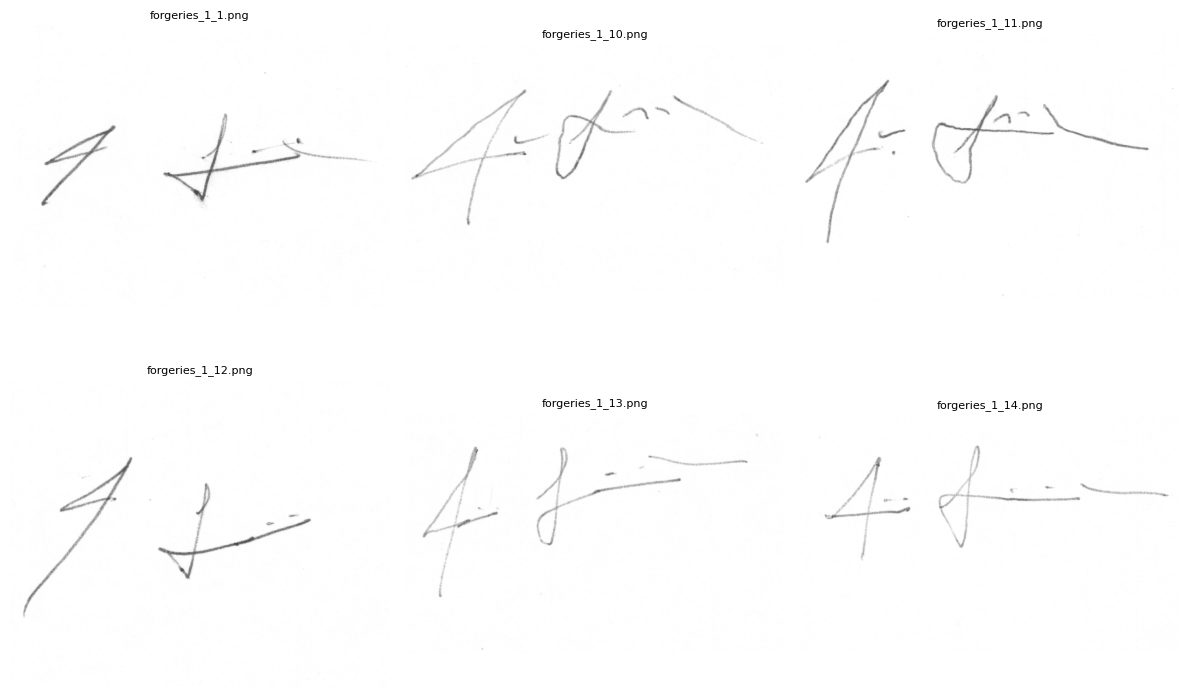

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(12,8))

for i, ax in enumerate(axes.flat):
    img_path = os.path.join(folder, images[i])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(images[i], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [17]:
def preprocess_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (200, 100))

    img = cv2.GaussianBlur(img, (3, 3), 0)
    _, img = cv2.threshold(
        img,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    return img

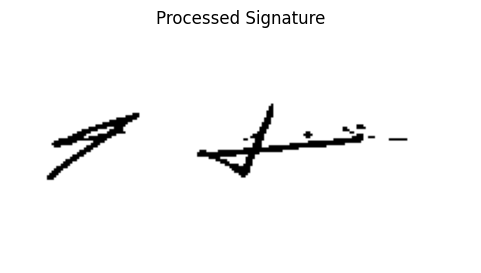

In [18]:
sample_path = os.path.join(folder, images[0])

processed = preprocess_image(sample_path)

plt.figure(figsize=(6,3))
plt.imshow(processed, cmap='gray')
plt.title("Processed Signature")
plt.axis("off")
plt.show()

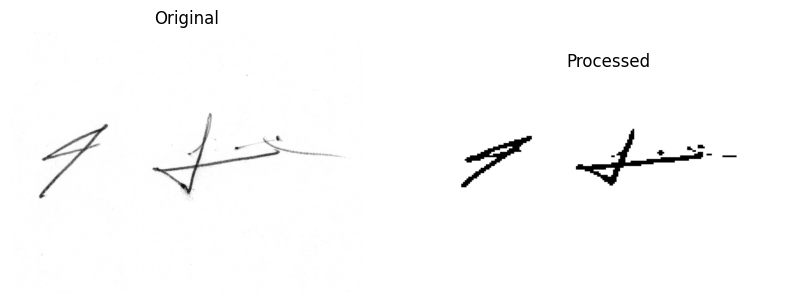

In [19]:
original = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

processed = preprocess_image(sample_path)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(original, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(processed, cmap="gray")
plt.title("Processed")
plt.axis("off")

plt.show()

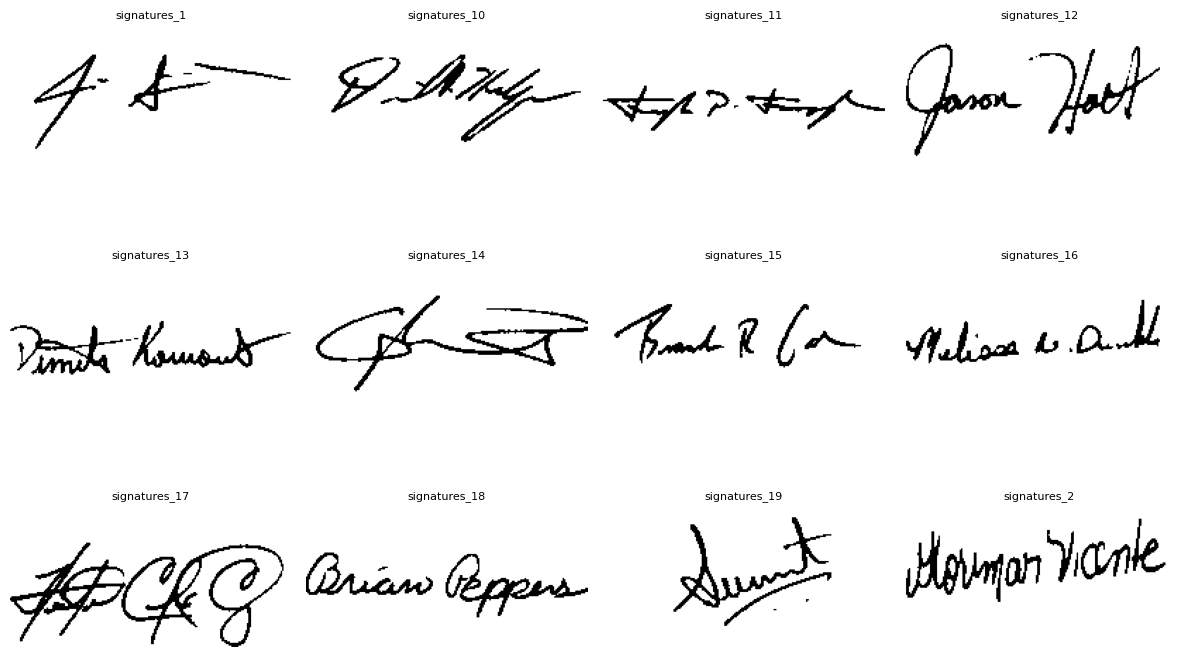

In [20]:
fig, axes = plt.subplots(3, 4, figsize=(12, 8))
count = 0
for ax in axes.flat:
    writer = writers[count]
    folder = os.path.join(DATASET_PATH, writer)

    files = os.listdir(folder)

    # Pick the first original signature
    for file in files:
        if file.startswith("original"):
            img_path = os.path.join(folder, file)
            break

    processed = preprocess_image(img_path)

    ax.imshow(processed, cmap="gray")
    ax.set_title(writer, fontsize=8)
    ax.axis("off")

    count += 1

plt.tight_layout()
plt.show()

In [21]:
sample = preprocess_image(sample_path)

features, hog_image = hog(
    sample,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True,
    block_norm="L2-Hys"
)

print("Feature Vector Length :", len(features))

Feature Vector Length : 9504


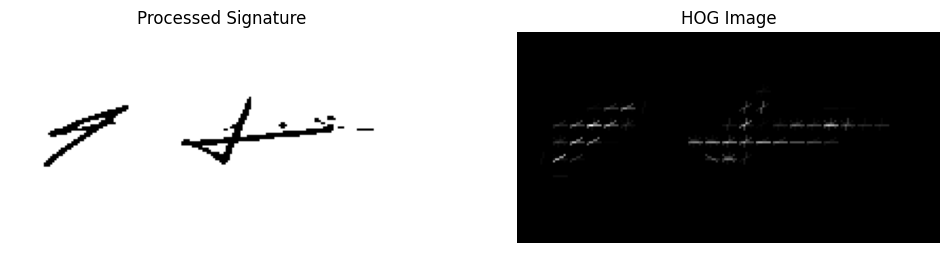

In [22]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(sample,cmap="gray")
plt.title("Processed Signature")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(hog_image,cmap="gray")
plt.title("HOG Image")
plt.axis("off")

plt.show()

In [23]:
print(features[:20])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [25]:
X = []
Y = []

In [26]:
for writer in tqdm(writers):
    folder = os.path.join(DATASET_PATH, writer)
    
    for file in os.listdir(folder):
        image_path = os.path.join(folder, file)
        img = preprocess_image(image_path)
        features = hog(
            img,
            orientations=9,
            pixels_per_cell=(8,8),
            cells_per_block=(2,2),
            visualize=False,
            block_norm="L2-Hys"
        )
        X.append(features)
        # Assign labels
        if file.startswith("original"):
            Y.append(1)

        elif file.startswith("forgeries"):
            Y.append(0)

100%|██████████████████████████████████████████████████████████████████████████████████| 55/55 [00:35<00:00,  1.53it/s]


In [27]:
X = np.array(X)
Y = np.array(Y)

In [28]:
print("Feature Matrix Shape :", X.shape)
print("Labels Shape :", Y.shape)

Feature Matrix Shape : (2640, 9504)
Labels Shape : (2640,)


In [29]:
print("Original :", np.sum(Y == 1))
print("Forged   :", np.sum(Y == 0))

Original : 1320
Forged   : 1320


In [30]:
print(X.shape)
print(Y.shape)

print(np.sum(Y == 1))
print(np.sum(Y == 0))

(2640, 9504)
(2640,)
1320
1320


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)

In [32]:
print(X_train.shape)
print(X_test.shape)

(2112, 9504)
(528, 9504)


In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
from sklearn.svm import SVC

model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    random_state=42
)

In [35]:
model.fit(X_train, y_train)

,C,10
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [36]:
y_pred = model.predict(X_test)

In [37]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy*100:.2f}%")
print(classification_report(y_test, y_pred))

Accuracy : 87.31%
              precision    recall  f1-score   support

           0       0.87      0.88      0.87       264
           1       0.87      0.87      0.87       264

    accuracy                           0.87       528
   macro avg       0.87      0.87      0.87       528
weighted avg       0.87      0.87      0.87       528



In [38]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[231  33]
 [ 34 230]]


In [ ]:
import joblib

joblib.dump(model, "../model/signature_model.pkl")
joblib.dump(scaler, "../model/scaler.pkl")